# Part 1 — Forecast 2 m temperature with and without Anemoi

> **Extra, read only.** This lecture notebook is kept with its saved outputs. It ran with anemoi-training 0.17 and anemoi-inference 0.12 on the lecture dataset, not with the course kernel, so read it but do not rerun it in class.

**Slides 1–3 · 20 min.** Slide 2's four definitions (state, data, model + loss, rollout), each done twice: with `numpy` and one parameter, then with the Anemoi package that owns it. Three forecasts of `2t`, 48 h from 2021-07-01 00:00, one RMSE scoreboard.

**Prerequisites:** the O48 dataset zip, `graph/graph_o48_tri4.pt`, `checkpoints/course-o48-gt128.ckpt` (runbook Phases 1–4); one GPU (the MN5 acc login nodes have H100s).

Tags: `# RUN` = execute now · `# REVIEW` = shown in the 30-minute review.

In [1]:
# RUN — paths, quiet logging, versions
import os
import time
import warnings
import logging
import importlib
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")                          # hide library deprecation notices
for name in ("pytorch_lightning", "lightning_fabric", "lightning", "anemoi"):
    logging.getLogger(name).setLevel(logging.ERROR)        # keep the cells quiet

# where things are: <repo>/data/anemoi-course, or the folder named in ANEMOI_COURSE_BASE
BASE  = Path(os.environ.get("ANEMOI_COURSE_BASE", "../../../data/anemoi-course")).resolve()
DATA  = BASE / "data" / "era5-o48-2020-2021-6h-v1.zip"    # the course dataset: a zarr store inside a zip
GRAPH = BASE / "graph" / "graph_o48_tri4.pt"              # the graph built in Part 3
CK    = BASE / "checkpoints" / "course-o48-gt128.ckpt"    # the checkpoint trained in Part 4
FC    = BASE / "forecast"                                 # where this notebook writes its forecast
for path in (DATA, GRAPH, CK):
    assert path.exists(), f"missing {path}"

versions = []                                              # one "package version" string per Anemoi package
for module_name in ["anemoi.datasets", "anemoi.graphs", "anemoi.models", "anemoi.training", "anemoi.inference"]:
    module = importlib.import_module(module_name)          # import the package from its name
    short_name = module_name.split(".")[1]                 # "anemoi.datasets" -> "datasets"
    versions.append(f"{short_name} {module.__version__}")
print("versions:", ", ".join(versions))

versions: datasets 0.5.43, graphs 0.9.7, models 0.19.0, training 0.17.0, inference 0.12.0


**Expected:** `datasets 0.5.43, graphs 0.9.7, models 0.19.0, training 0.17.0, inference 0.12.0`.
The course configuration format is anemoi-training 0.17 (slide 3).

## 1 · The state $X_t$ (slide 2, definition 1)

$X_t \in \mathbb{R}^{N \times V}$ with $N = 10{,}944$ O48 points, $V = 43$ variables, $\Delta t = 6$ h. We keep one variable, `2t`, for 2020-01-01 … 2021-06-30.

In [2]:
# RUN — WITHOUT Anemoi: the zip is a zarr store; find 2t and the rows by hand
import zarr

store = zarr.ZipStore(str(DATA), mode="r")                 # the zip file, opened as a zarr store
root = zarr.open_group(store, mode="r")                    # its root group: the arrays "data", "dates", "latitudes", ...
variables = root.attrs["variables"]                        # the 43 variable names, in the order of the data array
i2t = variables.index("2t")                                # you must know the index of a variable
dates_all = root["dates"][:]                               # one date per row of the data array
lat = root["latitudes"][:]                                 # one latitude per grid point
lon = root["longitudes"][:]                                # one longitude per grid point

first = np.datetime64("2020-01-01T00:00")                  # the first date we keep
last = np.datetime64("2021-06-30T18:00")                   # the last date we keep
in_period = (dates_all >= first) & (dates_all <= last)     # True for the rows between the two
rows = np.nonzero(in_period)[0]                            # their row numbers

t0 = time.time()
X = root["data"][rows[0]:rows[-1] + 1, i2t, 0, :]         # (time, grid points): read only 2t, only these rows
dates = dates_all[rows]                                    # the date of every row of X
read_seconds = time.time() - t0
print("data", root["data"].shape, "| 2t is index", i2t)
print("X", X.shape, f"| {X.nbytes / 1e6:.0f} MB | read in {read_seconds:.0f} s |", dates[0], "→", dates[-1])

data (2924, 43, 1, 10944) | 2t is index 3
X (2188, 10944) | 96 MB | read in 21 s | 2020-01-01T00:00:00 → 2021-06-30T18:00:00


**Expected:** `data (2924, 43, 1, 10944)`, 2t is index 3; `X (2188, 10944)`, 96 MB, about 30 s.
Slide 2's $N = 10{,}944$ and $V = 43$ are the last and second axes.

In [3]:
# RUN — WITH Anemoi: names, dates and statistics come with the dataset
from anemoi.datasets import open_dataset

ds = open_dataset(DATA)                                                              # the whole dataset (metadata only, nothing read yet)
ds_2t = open_dataset(DATA, select=["2t"], start="2020-01-01", end="2021-06-30")     # only 2t, only our period (end is inclusive)

first_rows = np.asarray(ds_2t[:8])                         # the first 8 rows: (8, 1 variable, 1 ensemble member, grid points)
first_rows = first_rows[:, 0, 0, :]                        # drop the variable and ensemble axes -> (8, grid points)
assert np.array_equal(first_rows, X[:8])                   # the same bytes as the manual read
assert len(ds_2t.dates) == len(X)                          # and the same number of rows

i = ds.name_to_index["2t"]                                 # the index of a variable, looked up by name
mean_2t = ds.statistics["mean"][i]                         # the mean of 2t, stored with the dataset
stdev_2t = ds.statistics["stdev"][i]                       # and its standard deviation
print("ds.shape", ds.shape, "| frequency", ds.frequency, "| 2t is index", i)
print("select/start/end →", ds_2t.shape, "— same bytes as the manual read")
print(f"statistics for 2t: mean {mean_2t:.2f} K, stdev {stdev_2t:.2f} K")

ds.shape (2924, 43, 1, 10944) | frequency 6:00:00 | 2t is index 3
select/start/end → (2188, 1, 1, 10944) — same bytes as the manual read
statistics for 2t: mean 287.83 K, stdev 16.14 K


**Expected:** `frequency 6:00:00`, `(2188, 1, 1, 10944)`, mean 287.83 K, stdev 16.14 K.
Same bytes; Anemoi adds names, dates and the $\mu_v, \sigma_v$ the model normalises with (`system.input.dataset`, `data.normalizer`).

## 2 · Training pairs and periods (definition 2)

One example is $(X_{t-\Delta t}, X_t) \rightarrow X_{t+\Delta t}$: three consecutive rows. Train on 2020, validate on 2021-01 … 2021-06.

In [4]:
# RUN — date masks and three consecutive rows
is_train = dates < np.datetime64("2021-01-01")             # True for the 2020 rows
X_train = X[is_train]                                      # 2020
X_val = X[~is_train]                                       # 2021-01 ... 2021-06


def make_pairs(Xb):
    # three consecutive rows of a block: X_{t-dt}, X_t  ->  X_{t+dt}
    Xm1 = Xb[:-2]                                          # the state one step before
    X0 = Xb[1:-1]                                          # the current state
    X1 = Xb[2:]                                            # the state one step after: the target
    return Xm1, X0, X1


Xm1_tr, X0_tr, X1_tr = make_pairs(X_train)
Xm1_va, X0_va, X1_va = make_pairs(X_val)
print("train rows", len(X_train), "→ pairs", len(X0_tr), "| validation rows", len(X_val), "→ pairs", len(X0_va))

train rows 1464 → pairs 1462 | validation rows 724 → pairs 722


**Expected:** train 1464 rows → 1462 pairs; validation 724 rows → 722 pairs.
In Anemoi the periods are `dataloader.{training,validation,test}.datasets.data.{start,end}`; the window is `task.multistep_input: 2`, `task.timestep: 6h`.

## 3 · Loss and model (definitions 3 and 4)

Loss with $R = 1$, $w_v = 1$: $\sqrt{\tfrac{1}{T}\sum_t \sum_i a_i (\hat x_{t,i} - x_{t,i})^2}$ in kelvin. Baseline: **persistence** $\hat X_{t+\Delta t} = X_t$.
Without Anemoi, $f_\theta$ is one number: $\hat X_{t+\Delta t} = X_t + \theta\,(X_t - X_{t-\Delta t})$, fitted by least squares in closed form.

In [5]:
# RUN — the area weight a_i of every grid point, by hand, then compared with graph.pt
row_lat, row_n = np.unique(lat, return_counts=True)       # the 96 latitude rows of the O48 grid, and the points per row
mid = (row_lat[:-1] + row_lat[1:]) / 2                    # the latitude halfway between two neighbouring rows
edges = np.concatenate([[-90.0], mid, [90.0]])            # the edges of the 96 latitude bands
band = np.sin(np.deg2rad(edges[1:])) - np.sin(np.deg2rad(edges[:-1]))   # area of each band on the unit sphere (up to a constant)
row_of_point = np.searchsorted(row_lat, lat)              # the row of every grid point
a = (band / row_n)[row_of_point]                          # area of a point = area of its band / points in that band
a = a / a.sum()                                           # weights sum to 1
ratio = a.max() / a.min()                                 # largest weight / smallest weight

graph = torch.load(GRAPH, map_location="cpu", weights_only=False)     # the graph of Part 3
a_graph = graph["data"]["area_weight"].numpy().ravel()    # the area weight Anemoi stores on the data nodes
mismatch = np.abs(a / a.max() - a_graph / a_graph.max()).max()        # both scaled so the largest weight is 1
print(f"area weights: {len(row_lat)} rows, {row_n.min()}–{row_n.max()} points per row, max/min {ratio:.1f}")
print(f"graph.pt agrees to {mismatch:.4f}")

area weights: 96 rows, 20–208 points per row, max/min 4.8
graph.pt agrees to 0.0015


**Expected:** 96 rows, 20–208 points per row, max/min 4.8; graph.pt agrees to 0.0015.

In [6]:
# RUN — theta in closed form on the training pairs, then the 6 h RMSE against persistence
def rmse(pred, truth):
    # area-weighted root-mean-square error in kelvin; the mean is over the pairs
    sq_err = (pred - truth) ** 2                           # squared error at every grid point
    weighted = (sq_err * a).sum(axis=-1)                   # weighted sum over the grid -> one number per pair
    return float(np.sqrt(weighted.mean()))


def forecast(Xm1, X0, theta):
    # the one-parameter model: X_{t+dt} = X_t + theta * (X_t - X_{t-dt})
    return X0 + theta * (X0 - Xm1)


d = X0_tr - Xm1_tr                                         # the last tendency: the change we know
r = X1_tr - X0_tr                                          # the next tendency: the change we want
theta = float((a * d * r).sum() / (a * d * d).sum())       # least squares in closed form, area-weighted

pers_train = rmse(X0_tr, X1_tr)                            # persistence: the forecast is the current state
pers_val = rmse(X0_va, X1_va)
one_train = rmse(forecast(Xm1_tr, X0_tr, theta), X1_tr)    # the one-parameter model
one_val = rmse(forecast(Xm1_va, X0_va, theta), X1_va)
print(f"theta* = {theta:+.4f}  (1 parameter, closed form on {len(d)} pairs)")
print(f"6 h RMSE  persistence  : train {pers_train:.3f} K  validation {pers_val:.3f} K")
print(f"6 h RMSE  one parameter: train {one_train:.3f} K  validation {one_val:.3f} K")

theta* = -0.0853  (1 parameter, closed form on 1462 pairs)
6 h RMSE  persistence  : train 2.816 K  validation 2.871 K
6 h RMSE  one parameter: train 2.805 K  validation 2.862 K


**Expected:** $\theta^\star = -0.0853$; validation RMSE 2.871 K (persistence) vs 2.862 K (one parameter).
One parameter buys a hundredth of a kelvin; the graph's `area_weight` is the $a_i$ of slide 2 (`training.scalers.node_weights`).

> **Checkpoint:** which value of $\theta$ is persistence, and where is the residual $X_t + f_\theta(\dots)$ in Anemoi's model?

## 4 · Rollout: 48 h from 2021-07-01 00:00 (definition 4)

Each output becomes the next input. Truth for 2021-07-01 … 07-03 lies in the test period.

In [7]:
# RUN — WITHOUT Anemoi: the rollout is a for loop
ds_roll = open_dataset(DATA, select=["2t"], start="2021-06-30T18:00:00", end="2021-07-03T00:00:00")   # 10 rows: 2 inputs + 8 targets
R = np.asarray(ds_roll[:])[:, 0, 0, :]                     # -> (10, grid points)
lead_h = 6 * np.arange(1, 9)                               # the lead times: 6, 12, ..., 48 h
truth = R[2:]                                              # rows 0-1 = inputs (t-6h, t), rows 2-9 = the targets

Xm1 = R[0]                                                 # the state at t-6h
X0 = R[1]                                                  # the state at t = 2021-07-01 00:00
preds = []                                                 # one forecast per lead time
for lead in lead_h:
    X1 = forecast(Xm1, X0, theta)                          # one call of Phi_theta
    preds.append(X1)
    Xm1 = X0                                               # the output becomes the next input
    X0 = X1

err_pers = []                                              # persistence: the state at t, unchanged, at every lead
err_1p = []                                                # the one-parameter rollout
for k in range(8):
    err_pers.append(rmse(R[1], truth[k]))
    err_1p.append(rmse(preds[k], truth[k]))
print(f"model calls: {len(preds)} | +6 h RMSE  persistence {err_pers[0]:.3f} K  one parameter {err_1p[0]:.3f} K")

model calls: 8 | +6 h RMSE  persistence 2.886 K  one parameter 2.891 K


**Expected:** 8 model calls; +6 h RMSE 2.886 K (persistence) vs 2.891 K (one parameter).
Two input states in, eight states out — the same contract the checkpoint will have.

In [8]:
# RUN — WITH Anemoi: the checkpoint (encoder → processor → decoder) rolled out by anemoi-inference on the GPU
import xarray as xr
from anemoi.inference.config.run import RunConfiguration
from anemoi.inference.runners import create_runner

net = torch.load(CK, map_location="cpu", weights_only=False).model    # the trained network inside the checkpoint
n_par = 0
for p in net.parameters():
    n_par = n_par + p.numel()                              # count the numbers in every weight tensor

FC.mkdir(parents=True, exist_ok=True)
fc_path = FC / "part1_forecast_2021070100.nc"              # the forecast file this cell writes
cfg = RunConfiguration(
    checkpoint=str(CK),                                    # the model
    date="2021-07-01T00:00:00",                            # the start date; the runner reads t-6h and t from the dataset
    lead_time=48,                                          # hours: 8 steps of 6 h
    input={"dataset": str(DATA)},                          # where the input states come from
    output={"netcdf": {"path": str(fc_path)}},             # where the forecast goes
    write_initial_state=True,                              # also write the state at t, as time 0
    device="cuda",                                         # the GPU
    verbosity=0,
)
t0 = time.time()
runner = create_runner(cfg)
runner.execute()                                           # the eight model calls
run_seconds = time.time() - t0

fc = xr.open_dataset(fc_path)                              # time 0 = initial state, 1..8 = lead times
err_anemoi = []
for k in range(8):
    err_anemoi.append(rmse(fc["2t"].values[k + 1], truth[k]))
print(f"{CK.name}: {n_par:,} parameters vs 1 | 8 steps in {run_seconds:.0f} s → {fc_path.name} | +6 h RMSE {err_anemoi[0]:.3f} K")

course-o48-gt128.ckpt: 4,593,998 parameters vs 1 | 8 steps in 2 s → part1_forecast_2021070100.nc | +6 h RMSE 2.450 K


**Expected:** 4,593,998 parameters; 8 steps in a few seconds; +6 h RMSE 2.450 K.
The checkpoint carries $\theta$, the graph, the statistics and the configuration, so inference needs only a date and a dataset (slide 3).

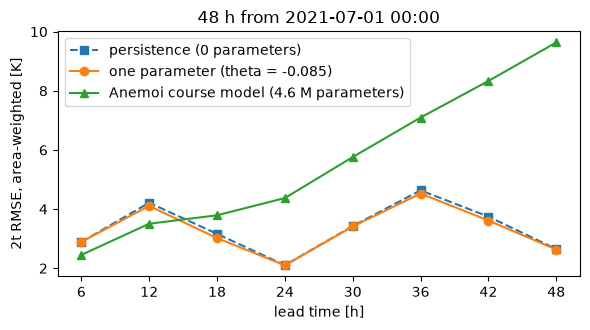

  lead  persist  1-param   anemoi   winner
   6 h    2.886    2.891    2.450   anemoi
  12 h    4.215    4.109    3.505   anemoi
  18 h    3.162    3.019    3.791   one parameter
  24 h    2.101    2.097    4.374   one parameter
  30 h    3.426    3.412    5.760   one parameter
  36 h    4.633    4.525    7.095   one parameter
  42 h    3.746    3.614    8.333   one parameter
  48 h    2.648    2.629    9.634   one parameter


In [9]:
# REVIEW — the scoreboard: same date, same grid, same metric
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(lead_h, err_pers, "s--", label="persistence (0 parameters)")
ax.plot(lead_h, err_1p, "o-", label=f"one parameter (theta = {theta:+.3f})")
ax.plot(lead_h, err_anemoi, "^-", label=f"Anemoi course model ({n_par / 1e6:.1f} M parameters)")
ax.set_xlabel("lead time [h]")
ax.set_ylabel("2t RMSE, area-weighted [K]")
ax.set_xticks(lead_h)
ax.set_title("48 h from 2021-07-01 00:00")
ax.legend()
fig.tight_layout()
fig.savefig("part1-rmse.png", dpi=90)
plt.show()

print(f"{'lead':>6} {'persist':>8} {'1-param':>8} {'anemoi':>8}   winner")
for k in range(8):
    errors = {"persistence": err_pers[k], "one parameter": err_1p[k], "anemoi": err_anemoi[k]}
    winner = min(errors, key=errors.get)                   # the name whose error is the smallest
    print(f"{lead_h[k]:>4} h {err_pers[k]:8.3f} {err_1p[k]:8.3f} {err_anemoi[k]:8.3f}   {winner}")

**Expected:** Anemoi wins at +6 h (2.450 K) and +12 h (3.505 K); from +18 h the one-parameter line wins and the course model drifts to ≈ 9.63 K at +48 h.
Five epochs on one year beat persistence at short leads only: a falling one-step loss (Part 4) does not guarantee rollout skill (Part 5).

> **Checkpoint:** why is the persistence error not monotonic in lead time (look at +12 h and +24 h)?

## 5 · Slide 3: term → package → configuration key

| Term | Without Anemoi | With Anemoi | Configuration key |
|---|---|---|---|
| state $X_t$ | `zarr.ZipStore`, index by hand | `open_dataset(select, start, end)`, `ds.statistics` | `system.input.dataset` |
| pairs, periods | date masks, three rows | periods as arguments; windows by the loader | `dataloader.*.datasets.data.{start,end}`, `task.multistep_input`, `task.timestep` |
| loss, $a_i$ | band area / points per row | `area_weight` on the graph's data nodes | `graph.nodes.data.attributes.area_weight`, `training.scalers.node_weights` |
| model $f_\theta$, fit | one parameter, closed form | encoder → processor → decoder, AdamW on GPU | `model.*`, `training.training_loss`, `training.optimization` |
| rollout | a `for` loop | `anemoi-inference run inference.yaml` | `checkpoint`, `date`, `lead_time: 48`, `input` |